In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Logistic Regression (Binary Classification)

**Step 1: Compute the logit (linear combination)**
$$ X\theta = z $$

$$ X_i \theta = z_i $$

**Step 2: Apply the sigmoid (logistic) function to find probability**
$$h = \sigma(z)$$

$$h_i = \sigma(z_i) = \frac{1}{1 + e^{-z_i}}$$

**Step 3: Apply decision rule**
$$\hat{y}_i = \begin{cases} 1 & \text{if } \sigma(z_i) \geq 0.5 \\ 0 & \text{if } \sigma(z_i) < 0.5 \end{cases}$$

Since $\sigma(z_i) \geq 0.5$ when $z_i \geq 0$, this is equivalent to:
$$\hat{y}_i = \begin{cases} 1 & \text{if } z_i \geq 0 \\ 0 & \text{if } z_i < 0 \end{cases}$$

**The Sigmoid Function Properties:**
- Output range: $(0, 1)$ - perfect for probabilities
- $\sigma(0) = 0.5$ - decision boundary
- As $z \to \infty$, $\sigma(z) \to 1$
- As $z \to -\infty$, $\sigma(z) \to 0$
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$


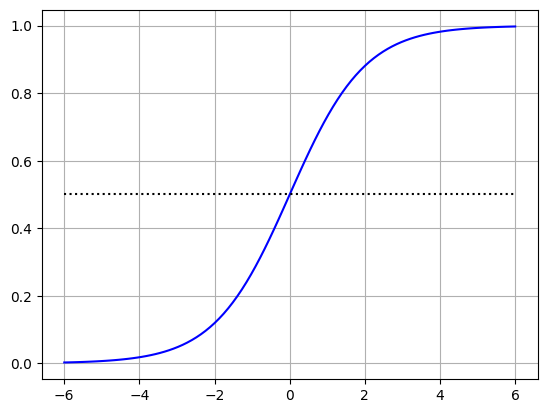

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x_coords = np.linspace(-6, 6, 100)
plt.plot(
    x_coords, 
    sigmoid(x_coords), 
    "b-", 
    label="Probability",
)
plt.hlines([0.5], -6, 6, "k", "dotted", label="Threshold")
plt.grid(True)
plt.show()

In [3]:
# System: 
# 170theta1 + 25theta2 + theta3 = 0     # 7
# 180theta1 + 30theta2 + theta3 = 0     # 8
# 200theta1 + 35theta2 + theta3 = 1     # 12

X = np.array([
    [170, 25, 1],
    [180, 30, 1],
    [200, 35, 1]
])
y = np.array([0, 0, 1])
theta = np.array([  0.3,  -0.4, -43. ])

# step 1
z = X @ theta

# step 2
h = sigmoid(z)

# step 3
y_pred = (h >= 0.5).astype(int)
y_pred


array([0, 0, 1])

# Binary classification - logistic regression

## cost function

$$\begin{align*}
J(\mathbf{\theta}) &= -\frac{1}{m} \left( \mathbf{y}^T \log(\mathbf{h}) + (\mathbf{1} - \mathbf{y})^T \log(\mathbf{1} - \mathbf{h}) \right) \\
&= -\frac{1}{m} \sum_{i=1}^{m} \big[ y_{i} \log(h_i) + (1-y_{i}) \log(1-h_i) \big] \\
\end{align*}$$

where $\mathbf{h} = \sigma(\mathbf{X}\mathbf{\theta})$.


**Intuition:**
- If $y=1$ and prediction $\approx 1$: cost $\approx 0$
- If $y=1$ and prediction $\approx 0$: cost $\to \infty$
- If $y=0$ and prediction $\approx 0$: cost $\approx 0$
- If $y=0$ and prediction $\approx 1$: cost $\to \infty$

### Gradient for Gradient Descent

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_i - y_i) X_{ij}$$

In vector form:
$$\nabla J(\mathbf{\theta}) = \frac{1}{m} \mathbf{X}^T (\mathbf{h} - \mathbf{y})$$

Where $\mathbf{h} = \sigma(\mathbf{X}\mathbf{\theta})$ 

**Note:** This looks identical to linear regression, but $\mathbf{h}$ is now the sigmoid output!

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target_names[iris.target] == 'virginica').astype(int)[:, np.newaxis]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

In [42]:
from sklearn.preprocessing import add_dummy_feature

X_train_b = add_dummy_feature(X_train)
X_train_b

array([[1. , 1.3, 0.4],
       [1. , 3.9, 1.2],
       [1. , 3.5, 1. ],
       [1. , 1.2, 0.2],
       [1. , 5.9, 2.3],
       [1. , 5.2, 2.3],
       [1. , 5.1, 1.9],
       [1. , 5.1, 2.4],
       [1. , 5.6, 2.4],
       [1. , 4. , 1.3],
       [1. , 1.5, 0.3],
       [1. , 1.3, 0.2],
       [1. , 5.1, 2. ],
       [1. , 1.7, 0.5],
       [1. , 1.5, 0.1],
       [1. , 4.7, 1.5],
       [1. , 4.6, 1.4],
       [1. , 4. , 1.3],
       [1. , 3.5, 1. ],
       [1. , 5.1, 1.9],
       [1. , 4.4, 1.4],
       [1. , 5.3, 2.3],
       [1. , 1.3, 0.3],
       [1. , 5.7, 2.1],
       [1. , 4.2, 1.2],
       [1. , 1.5, 0.4],
       [1. , 1.6, 0.2],
       [1. , 5.6, 1.8],
       [1. , 4.3, 1.3],
       [1. , 6.7, 2. ],
       [1. , 6.9, 2.3],
       [1. , 1.9, 0.4],
       [1. , 4.5, 1.5],
       [1. , 3.7, 1. ],
       [1. , 5.1, 1.8],
       [1. , 1.4, 0.1],
       [1. , 5.8, 1.6],
       [1. , 4.7, 1.6],
       [1. , 4.7, 1.4],
       [1. , 1.6, 0.2],
       [1. , 5.6, 2.1],
       [1. , 5. 

$$\nabla J(\mathbf{\theta}) = \frac{1}{m} \mathbf{X}^T (\mathbf{h} - \mathbf{y})$$

In [51]:
eta = 0.1
n_epochs = 30000
m = len(X_train_b)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((3, 1)) 

for epoch in range(n_epochs):
    z = X_train_b @ theta
    h = sigmoid(z)
    gradients = 1 / m * X_train_b.T @ (h - y_train)
    theta = theta - eta * gradients
    
theta

array([[-21.9374185 ],
       [  2.03116855],
       [  7.12019652]])

In [54]:
X_test_b = add_dummy_feature(X_test)

z_test = X_test_b @ theta
h_test = sigmoid(z_test)
h_test.round(2)


array([[0.21],
       [0.99],
       [0.99],
       [0.01],
       [0.  ],
       [0.65],
       [0.02],
       [0.  ],
       [0.  ],
       [0.01],
       [0.99],
       [0.  ],
       [0.02],
       [0.89],
       [1.  ],
       [1.  ],
       [0.  ],
       [0.  ],
       [0.08],
       [0.  ],
       [0.  ],
       [0.29],
       [0.  ],
       [0.7 ],
       [0.  ],
       [0.  ],
       [0.  ],
       [0.91],
       [1.  ],
       [0.  ],
       [0.98],
       [0.25],
       [0.  ],
       [0.  ],
       [0.  ],
       [0.  ],
       [1.  ],
       [0.  ]])

In [56]:
y_test_pred = np.where(h_test >= 0.5, 1, 0)
y_test_pred

array([[0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0]])

In [59]:
(y_test_pred == y_test).sum(), len(y_test)

(np.int64(36), 38)

## sklearn

In [61]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train.ravel())
log_reg.intercept_, log_reg.coef_

(array([-16.52619144]), array([[2.59294033, 2.1855874 ]]))

In [63]:
log_reg.predict_proba(X_test).round(2)

array([[0.63, 0.37],
       [0.09, 0.91],
       [0.06, 0.94],
       [0.95, 0.05],
       [1.  , 0.  ],
       [0.54, 0.46],
       [0.91, 0.09],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.92, 0.08],
       [0.15, 0.85],
       [1.  , 0.  ],
       [0.97, 0.03],
       [0.16, 0.84],
       [0.01, 0.99],
       [0.03, 0.97],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.78, 0.22],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.51, 0.49],
       [1.  , 0.  ],
       [0.47, 0.53],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.37, 0.63],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.03, 0.97],
       [0.57, 0.43],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.98, 0.02],
       [1.  , 0.  ],
       [0.01, 0.99],
       [1.  , 0.  ]])

In [ ]:
log_reg.predict(X_test) 

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0])

In [67]:
(log_reg.predict(X_test) == y_test.ravel()).sum(), len(y_test)

(np.int64(35), 38)

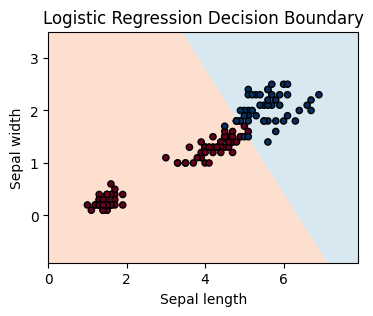

In [68]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

_, ax = plt.subplots(figsize=(4, 3))
DecisionBoundaryDisplay.from_estimator(
    log_reg,
    X,
    cmap=plt.cm.RdBu,
    ax=ax,
    response_method="predict_proba",
    plot_method="contourf",
    levels=[-1, 0, 0.5, 1, 2] # Contour levels, 0.5 is the boundary
)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolor="k", s=20)
ax.set_xlabel("Sepal length")
ax.set_ylabel("Sepal width")
ax.set_title("Logistic Regression Decision Boundary")
plt.show()

# Multiclass classification - softmax regression

**Step 1: Compute the logit (linear combination) for each class** 
$$ X\Theta = Z $$

$$ X_i \Theta = Z_i $$

Where 
- $\mathbf{X}$ is an $m \times n$ matrix. 
- $\mathbf{\Theta}$ is an $n \times K$ matrix.
- $\mathbf{Z}$ is an $m \times K$ matrix.


$$
X = \begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1n} \\
x_{21} & x_{22} & \cdots & x_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
x_{m1} & x_{m2} & \cdots & x_{mn}
\end{pmatrix} \in \mathbb{R}^{m \times n}
$$
$$
\Theta = \begin{pmatrix}
\theta_{11} & \theta_{12} & \cdots & \theta_{1K} \\
\theta_{21} & \theta_{22} & \cdots & \theta_{2K} \\
\vdots & \vdots & \ddots & \vdots \\
\theta_{n1} & \theta_{n2} & \cdots & \theta_{nK}
\end{pmatrix} \in \mathbb{R}^{n \times K}
$$
$$
Z = \begin{pmatrix}
X_1\Theta \\
X_2\Theta \\
\vdots \\
X_m\Theta
\end{pmatrix} \in \mathbb{R}^{m \times K}
$$

**Step 2: Apply the softmax function to find probability**
$$H = Softmax(Z)$$

$$
H_i = Softmax(Z_i) = \begin{pmatrix}
\frac{e^{Z_{i1}}}{\sum_{j=1}^{K} e^{Z_{ij}}} & \frac{e^{Z_{i2}}}{\sum_{j=1}^{K} e^{Z_{ij}}} & \cdots & \frac{e^{Z_{iK}}}{\sum_{j=1}^{K} e^{Z_{ij}}}
\end{pmatrix}
$$

**Step 3: Apply decision rule (class with highest probability)**
- ordinal encoding
$$\hat{y} = \underset{k \in \{{1, \dots, K}\}}{\text{argmax}} \ H$$

$$\hat{y}_i = \underset{k \in \{{1, \dots, K}\}}{\text{argmax}} \ H_i$$

**Softmax Properties**:
- All outputs are in $(0, 1)$
- Outputs sum to 1: $\sum_{k=1}^{K} P(y=k|\mathbf{x}) = 1$
- The class with the highest score gets the highest probability



### Cost function and gradient

$\mathbf{Y} \in \mathbb{R}^{m \times K}$ be the matrix of one-hot encoded labels,

$\mathbf{H} \in \mathbb{R}^{m \times K}$ be the matrix of predicted probabilities.

$\ln(\mathbf{H})$ denote the element‑wise (natural) logarithm.

$$J(\Theta) = -\frac{1}{m}\sum_{i=1}^{m} \sum_{k=1}^{K} \mathbf{Y}_{ik} (\ln \mathbf{H})_{ik}$$

$$\nabla J(\mathbf{\theta}) = \frac{1}{m} \mathbf{X}^T (\mathbf{H} - \mathbf{Y})$$

In [78]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

iris = load_iris(as_frame=True)

X = iris.data.values
y = OneHotEncoder().fit_transform(y).toarray()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

In [81]:
X_train[:5], y_train[:5]


(array([[5.4, 3.9, 1.3, 0.4],
        [5.8, 2.7, 3.9, 1.2],
        [5. , 2. , 3.5, 1. ],
        [5. , 3.2, 1.2, 0.2],
        [6.8, 3.2, 5.9, 2.3]]),
 array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.]]))

In [86]:
from sklearn.preprocessing import add_dummy_feature

X_train_b = add_dummy_feature(X_train)
X_train_b[:5]

array([[1. , 5.4, 3.9, 1.3, 0.4],
       [1. , 5.8, 2.7, 3.9, 1.2],
       [1. , 5. , 2. , 3.5, 1. ],
       [1. , 5. , 3.2, 1.2, 0.2],
       [1. , 6.8, 3.2, 5.9, 2.3]])

$$\nabla J(\mathbf{\theta}) = \frac{1}{m} \mathbf{X}^T (\mathbf{H} - \mathbf{Y})$$

In [108]:
# def softmax(Z):
#     exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
#     return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
def softmax(Z):
    exp_Z = np.exp(Z)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

x = np.array([
    [1. , 5.4, 3.9, 1.3, 0.4],
    [1. , 5.8, 2.7, 3.9, 1.2]
    ])
th = np.array([
	[ 0.30471708, -1.03998411,  0.7504512 ],
	[ 0.94056472, -1.95103519, -1.30217951],
	[ 0.1278404 , -0.31624259, -0.01680116],
	[-0.85304393,  0.87939797,  0.77779194],
	[ 0.0660307 ,  1.12724121,  0.46750934]
])

z = x@th
softmax(z).round(3)

array([[1.   , 0.   , 0.   ],
       [0.998, 0.   , 0.002]])

In [109]:
eta = 0.1
n_epochs = 30000

m,n = X_train_b.shape
n_classes = 3

rng = np.random.default_rng(seed=42)
Theta = rng.standard_normal((n, n_classes)) 

for epoch in range(n_epochs):
    Z = X_train_b @ Theta
    H = softmax(Z)
    gradients = 1 / m * X_train_b.T @ (H - y_train)
    Theta = Theta - eta * gradients 

Theta

array([[ 0.92960163,  4.86596243, -5.78037989],
       [ 1.91174845, -0.53232328, -3.69207515],
       [ 3.83444799,  1.00462981, -5.04428115],
       [-6.29105171,  0.5229482 ,  6.5722495 ],
       [-2.54571706, -3.12554831,  7.33204661]])

In [114]:
X_test_b = add_dummy_feature(X_test)
Z_test = X_test_b @ Theta
H_test = softmax(Z_test).round(2)
np.argmax(H_test, axis=1) == np.argmax(y_test, axis=1)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

# sklearn

In [118]:
X = iris.data.values 
y = iris.target.values 

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

softmax_reg = LogisticRegression()
softmax_reg.fit(X_train, y_train)
softmax_reg.intercept_, softmax_reg.coef_

(array([  9.58860032,   1.87493504, -11.46353536]),
 array([[-0.44761018,  0.86792964, -2.35836563, -0.98974545],
        [ 0.51526119, -0.24634842, -0.18000152, -0.87022082],
        [-0.06765101, -0.62158122,  2.53836715,  1.85996627]]))

In [120]:
y_pred = softmax_reg.predict(X_test)
y_pred

array([1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 1,
       0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0])

In [121]:
y_pred == y_test

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])